## 1️⃣ Libraries Import & Data Preparation

In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D

print("Matplotlib version:", plt.matplotlib.__version__)
plt.rcParams['figure.figsize'] = (10, 5)

Matplotlib version: 3.10.8


In [2]:
# CSV padhna aur zaroori NumPy arrays banana (data-prep, visualization ka focus nahi hai)
with open('Superstore.csv', 'r', encoding='latin1') as f:
    reader = csv.reader(f)
    header = next(reader)
    rows = [row for row in reader]

col_idx = {name: i for i, name in enumerate(header)}

sales    = np.array([float(r[col_idx['Sales']])   for r in rows])
quantity = np.array([float(r[col_idx['Quantity']]) for r in rows])
discount = np.array([float(r[col_idx['Discount']]) for r in rows])
profit   = np.array([float(r[col_idx['Profit']])   for r in rows])

category    = np.array([r[col_idx['Category']]     for r in rows])
subcategory = np.array([r[col_idx['Sub-Category']]  for r in rows])
region      = np.array([r[col_idx['Region']]        for r in rows])
segment     = np.array([r[col_idx['Segment']]       for r in rows])
ship_mode   = np.array([r[col_idx['Ship Mode']]     for r in rows])

order_date = np.array([np.datetime64(f"{r[col_idx['Order Date']].split('/')[2]}-"
                                      f"{int(r[col_idx['Order Date']].split('/')[0]):02d}-"
                                      f"{int(r[col_idx['Order Date']].split('/')[1]):02d}")
                        for r in rows], dtype='datetime64[D]')

print("Total records:", len(sales))

Total records: 9994


In [3]:
# Group-wise summaries jo hum charts mein use karenge
categories, cat_sales = np.unique(category, return_inverse=True)
cat_total_sales  = np.bincount(cat_sales, weights=sales)
cat_total_profit = np.bincount(cat_sales, weights=profit)

regions, reg_codes = np.unique(region, return_inverse=True)
reg_total_sales  = np.bincount(reg_codes, weights=sales)
reg_total_profit = np.bincount(reg_codes, weights=profit)

subcats, subcat_codes = np.unique(subcategory, return_inverse=True)
subcat_total_sales = np.bincount(subcat_codes, weights=sales)

# Month-wise total sales (for time series charts)
sort_idx = np.argsort(order_date)
dates_sorted = order_date[sort_idx]
sales_sorted = sales[sort_idx]
months_since_start = ((dates_sorted - dates_sorted[0]).astype('timedelta64[D]').astype(int) // 30)
n_months = months_since_start.max() + 1
monthly_sales = np.bincount(months_since_start, weights=sales_sorted, minlength=n_months)
month_x = np.arange(n_months)

print("Categories:", categories)
print("Regions:", regions)

Categories: ['Furniture' 'Office Supplies' 'Technology']
Regions: ['Central' 'East' 'South' 'West']


## 2️⃣ Figure & Axes — Basic Anatomy

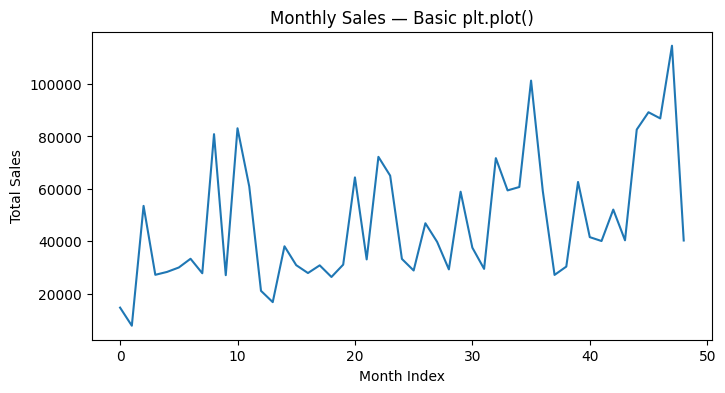

In [4]:
# plt.figure() aur plt.plot() ka sabse basic use
plt.figure(figsize=(8,4))
plt.plot(month_x, monthly_sales)
plt.title('Monthly Sales — Basic plt.plot()')
plt.xlabel('Month Index')
plt.ylabel('Total Sales')
plt.show()

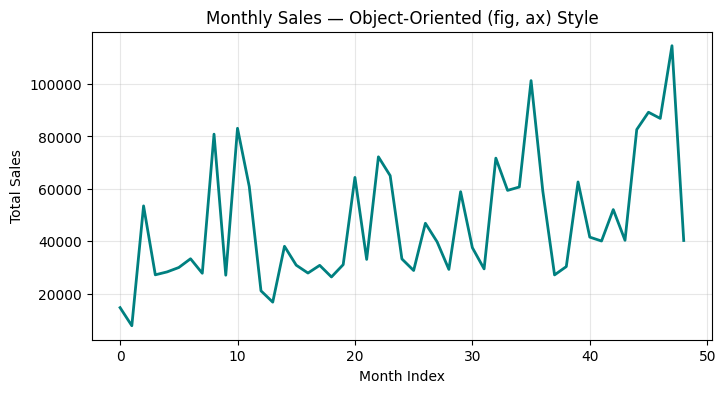

In [5]:
# Object-oriented approach - fig, ax = plt.subplots() (recommended professional style)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(month_x, monthly_sales, color='teal', linewidth=2)
ax.set_title('Monthly Sales — Object-Oriented (fig, ax) Style')
ax.set_xlabel('Month Index')
ax.set_ylabel('Total Sales')
ax.grid(True, alpha=0.3)
plt.show()

## 3️⃣ Line Plots — Styles, Markers, Multiple Lines

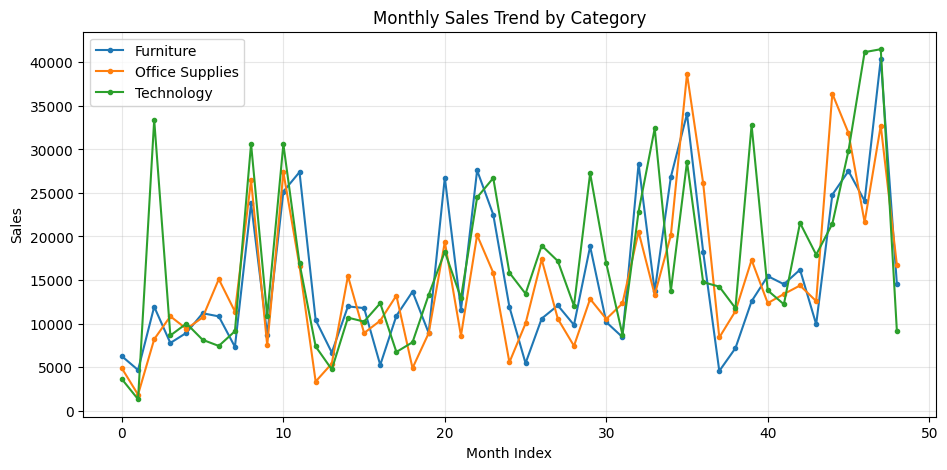

In [6]:
# Multiple lines ek hi plot mein - Category-wise monthly sales trend
fig, ax = plt.subplots(figsize=(11,5))
for cat in categories:
    mask = category[sort_idx] == cat
    cat_monthly = np.bincount(months_since_start[mask], weights=sales_sorted[mask], minlength=n_months)
    ax.plot(month_x, cat_monthly, marker='o', markersize=3, label=cat, linewidth=1.5)

ax.set_title('Monthly Sales Trend by Category')
ax.set_xlabel('Month Index')
ax.set_ylabel('Sales')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()

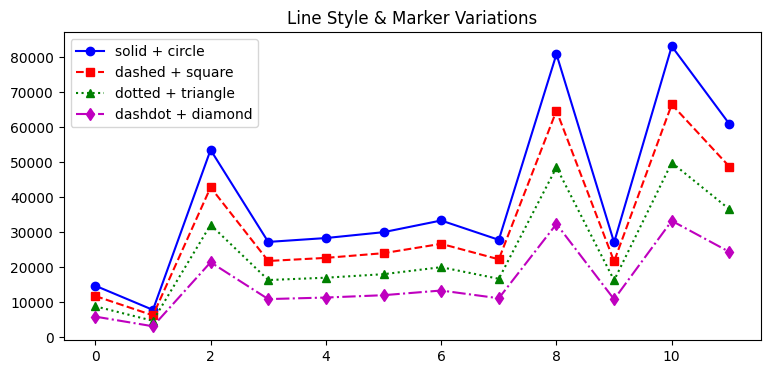

In [7]:
# Line style variations - solid, dashed, dotted, dashdot with different markers
fig, ax = plt.subplots(figsize=(9,4))
x_demo = np.arange(12)
ax.plot(x_demo, monthly_sales[:12], 'b-o', label='solid + circle')
ax.plot(x_demo, monthly_sales[:12]*0.8, 'r--s', label='dashed + square')
ax.plot(x_demo, monthly_sales[:12]*0.6, 'g:^', label='dotted + triangle')
ax.plot(x_demo, monthly_sales[:12]*0.4, 'm-.d', label='dashdot + diamond')
ax.set_title('Line Style & Marker Variations')
ax.legend()
plt.show()

## 4️⃣ Bar Charts — Vertical, Horizontal, Grouped, Stacked

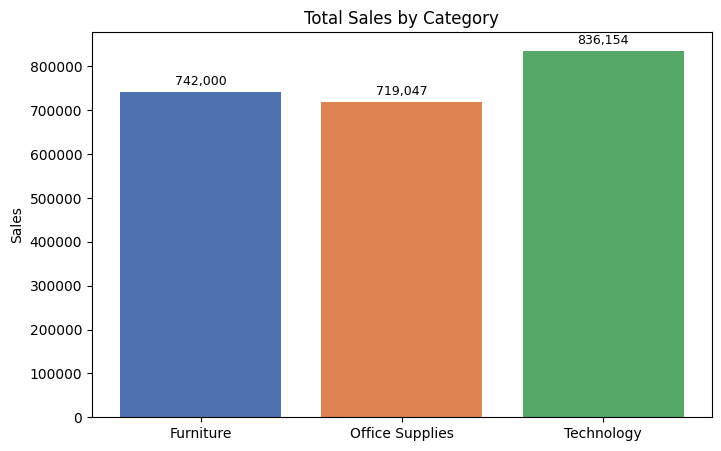

In [8]:
# Simple vertical bar chart
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(categories, cat_total_sales, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Total Sales by Category')
ax.set_ylabel('Sales')

# Bar ke upar value labels lagana
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,.0f}', xy=(bar.get_x()+bar.get_width()/2, height),
                xytext=(0,5), textcoords='offset points', ha='center', fontsize=9)
plt.show()

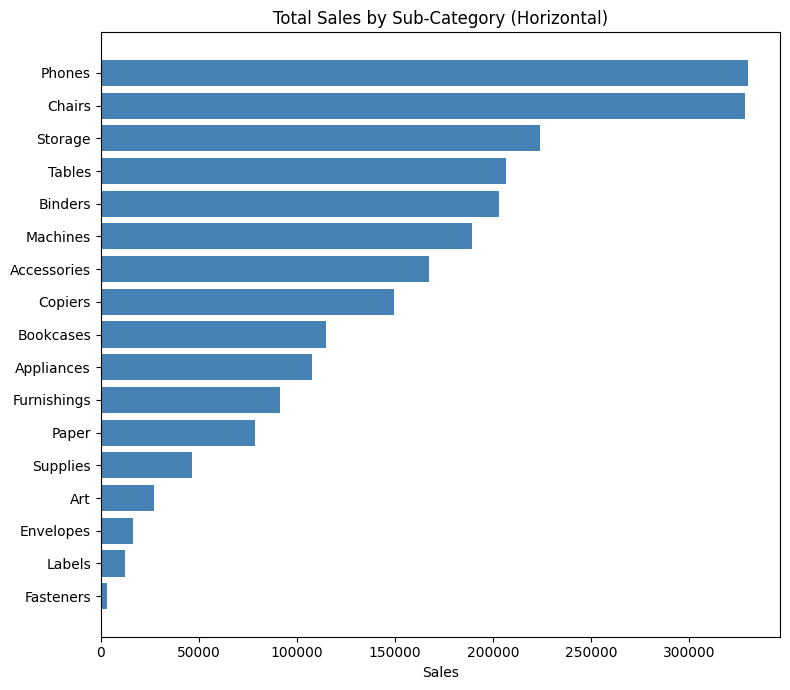

In [9]:
# Horizontal bar chart - Sub-Category wise sales (sorted)
order = np.argsort(subcat_total_sales)
fig, ax = plt.subplots(figsize=(8,7))
ax.barh(subcats[order], subcat_total_sales[order], color='steelblue')
ax.set_title('Total Sales by Sub-Category (Horizontal)')
ax.set_xlabel('Sales')
plt.tight_layout()
plt.show()

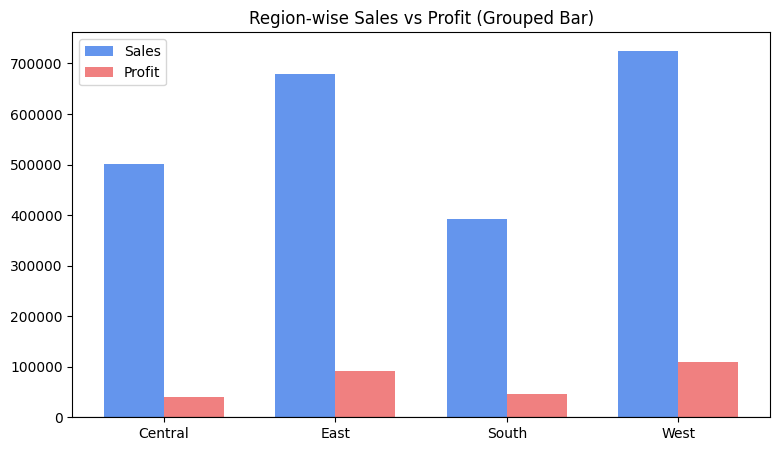

In [10]:
# Grouped bar chart - Region-wise Sales vs Profit side by side
x = np.arange(len(regions))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x - width/2, reg_total_sales, width, label='Sales', color='cornflowerblue')
ax.bar(x + width/2, reg_total_profit, width, label='Profit', color='lightcoral')
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_title('Region-wise Sales vs Profit (Grouped Bar)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
plt.show()

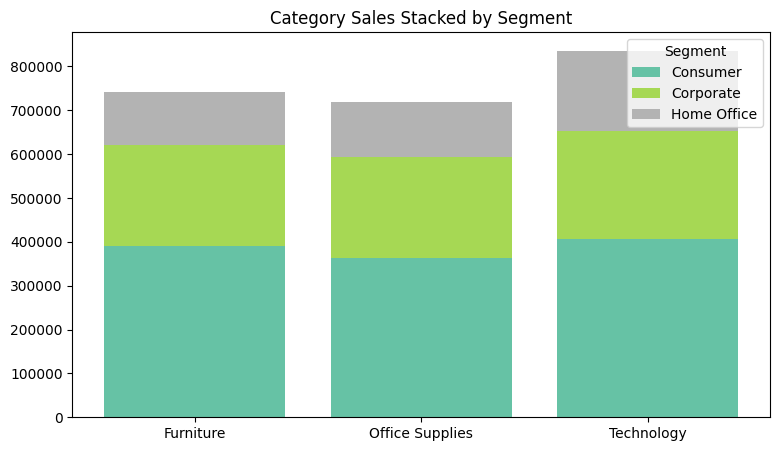

In [11]:
# Stacked bar chart - Segment-wise Category sales stacked
segments = np.unique(segment)
fig, ax = plt.subplots(figsize=(9,5))
bottom = np.zeros(len(categories))
colors_stack = plt.cm.Set2(np.linspace(0, 1, len(segments)))

for i, seg in enumerate(segments):
    seg_mask = segment == seg
    seg_cat_sales = np.array([sales[seg_mask & (category == c)].sum() for c in categories])
    ax.bar(categories, seg_cat_sales, bottom=bottom, label=seg, color=colors_stack[i])
    bottom += seg_cat_sales

ax.set_title('Category Sales Stacked by Segment')
ax.legend(title='Segment')
plt.show()

## 5️⃣ Histograms — Distribution Analysis

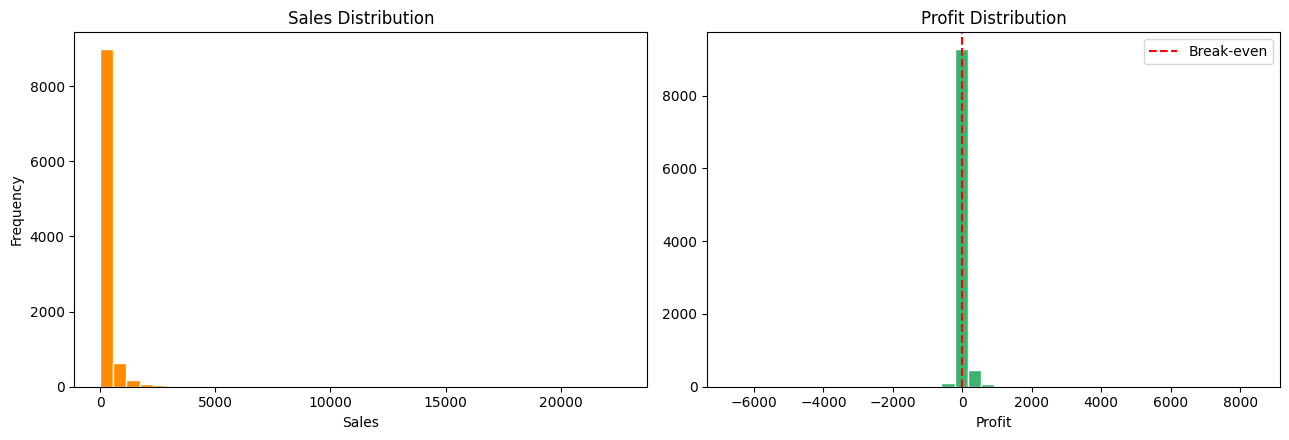

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

axes[0].hist(sales, bins=40, color='darkorange', edgecolor='white')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

axes[1].hist(profit, bins=40, color='mediumseagreen', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Break-even')
axes[1].set_title('Profit Distribution')
axes[1].set_xlabel('Profit')
axes[1].legend()

plt.tight_layout()
plt.show()

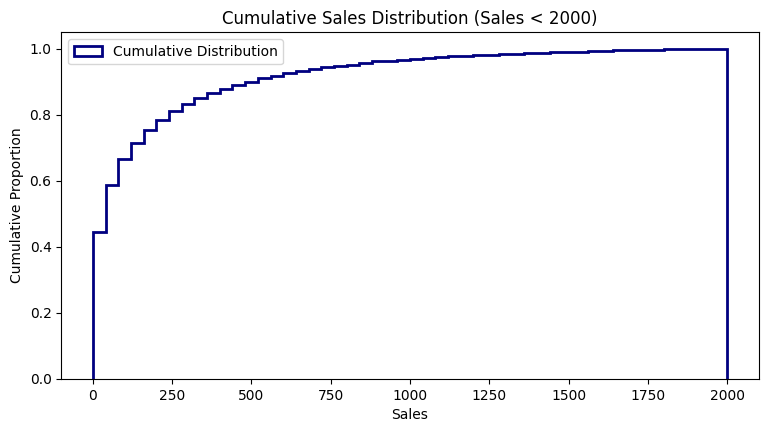

In [13]:
# Cumulative histogram + overlapping histograms
fig, ax = plt.subplots(figsize=(9,4.5))
ax.hist(sales[sales < 2000], bins=50, cumulative=True, density=True,
        histtype='step', color='navy', linewidth=2, label='Cumulative Distribution')
ax.set_title('Cumulative Sales Distribution (Sales < 2000)')
ax.set_xlabel('Sales')
ax.set_ylabel('Cumulative Proportion')
ax.legend()
plt.show()

## 6️⃣ Scatter Plots — Relationships & Bubble Charts

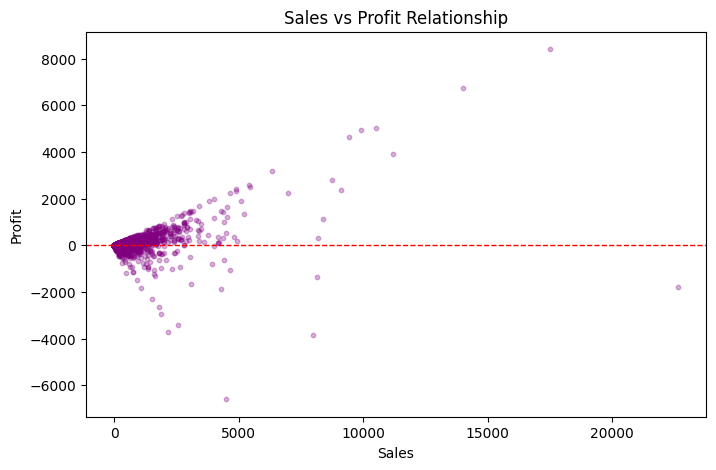

In [14]:
# Simple scatter - Sales vs Profit
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(sales, profit, alpha=0.3, s=10, color='purple')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Sales vs Profit Relationship')
ax.set_xlabel('Sales')
ax.set_ylabel('Profit')
plt.show()

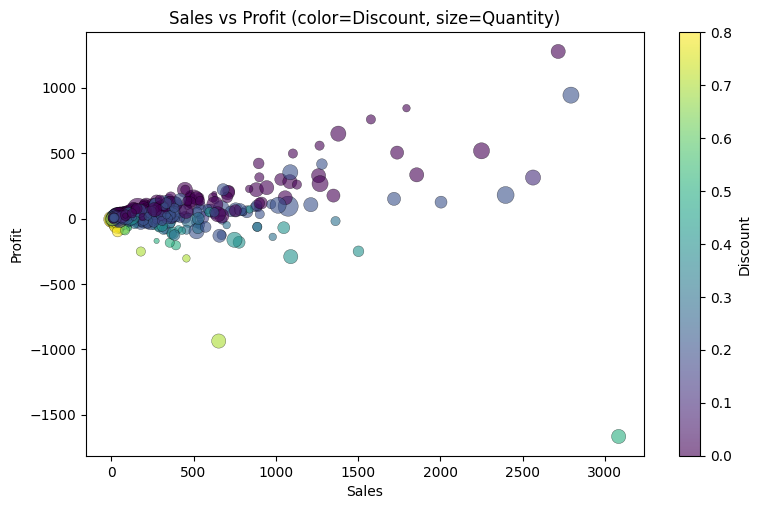

In [15]:
# Colormap scatter - color by Discount, size by Quantity (bubble chart)
fig, ax = plt.subplots(figsize=(9,5.5))
sample_idx = np.random.default_rng(1).choice(len(sales), 800, replace=False)
sc = ax.scatter(sales[sample_idx], profit[sample_idx],
                 c=discount[sample_idx], s=quantity[sample_idx]*15,
                 cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.3)
ax.set_title('Sales vs Profit (color=Discount, size=Quantity)')
ax.set_xlabel('Sales')
ax.set_ylabel('Profit')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Discount')
plt.show()

## 7️⃣ Pie Charts

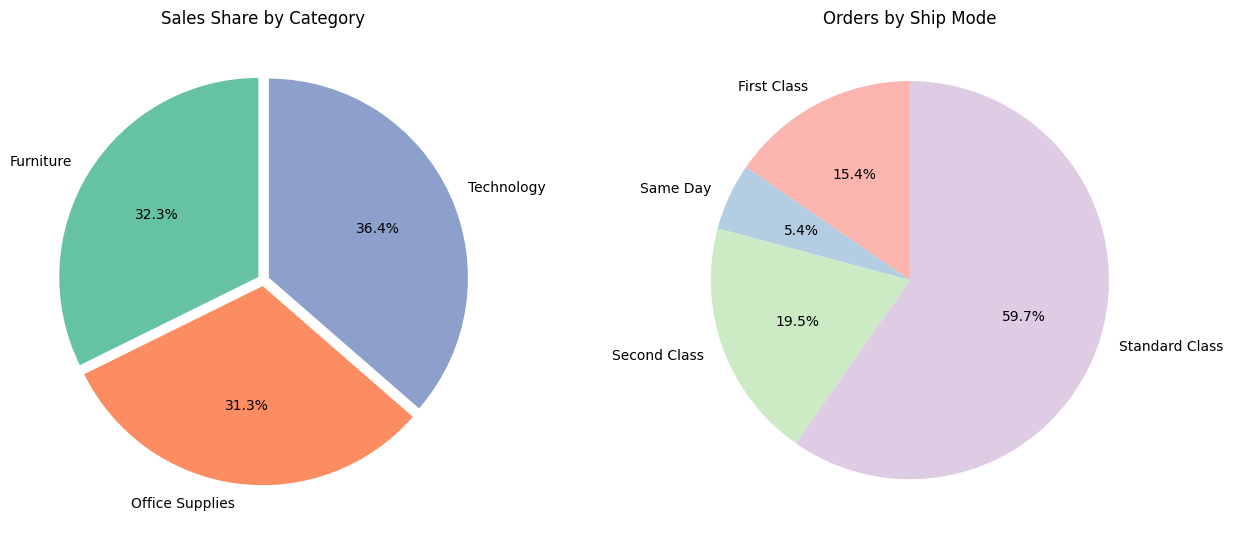

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

axes[0].pie(cat_total_sales, labels=categories, autopct='%1.1f%%', startangle=90,
            colors=['#66c2a5','#fc8d62','#8da0cb'], explode=[0.03]*len(categories))
axes[0].set_title('Sales Share by Category')

ship_modes, ship_counts = np.unique(ship_mode, return_counts=True)
axes[1].pie(ship_counts, labels=ship_modes, autopct='%1.1f%%', startangle=90,
            colors=plt.cm.Pastel1(np.arange(len(ship_modes))))
axes[1].set_title('Orders by Ship Mode')

plt.tight_layout()
plt.show()

## 8️⃣ Box Plots & Violin Plots

/tmp/ipykernel_485/2950909348.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat, labels=categories, patch_artist=True, showfliers=True)


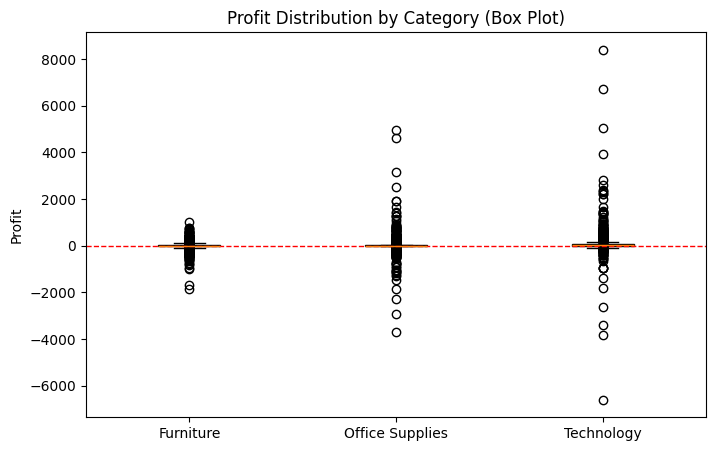

In [17]:
# Box plot - Category-wise Profit spread (outliers dikhte hain)
data_by_cat = [profit[category == c] for c in categories]

fig, ax = plt.subplots(figsize=(8,5))
bp = ax.boxplot(data_by_cat, labels=categories, patch_artist=True, showfliers=True)
for patch, color in zip(bp['boxes'], ['#8dd3c7','#ffffb3','#bebada']):
    patch.set_facecolor(color)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Profit Distribution by Category (Box Plot)')
ax.set_ylabel('Profit')
plt.show()

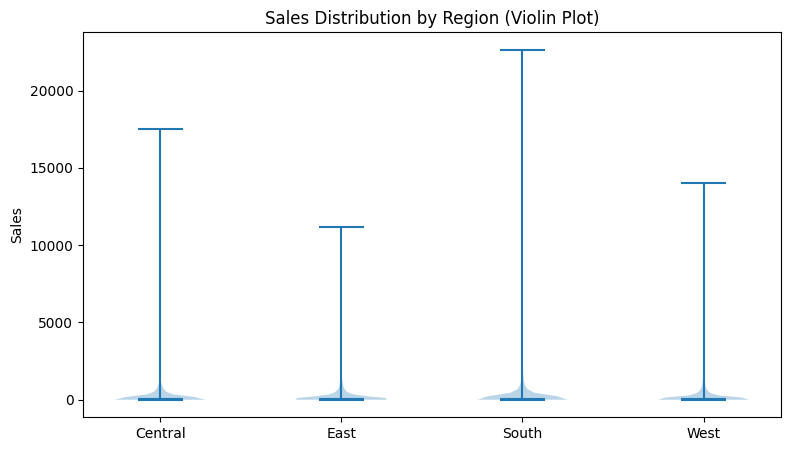

In [18]:
# Violin plot - Sales distribution by Region
data_by_region = [sales[region == r] for r in regions]

fig, ax = plt.subplots(figsize=(9,5))
parts = ax.violinplot(data_by_region, showmedians=True)
ax.set_xticks(np.arange(1, len(regions)+1))
ax.set_xticklabels(regions)
ax.set_title('Sales Distribution by Region (Violin Plot)')
ax.set_ylabel('Sales')
plt.show()

## 9️⃣ Advanced Layouts — subplot2grid & GridSpec

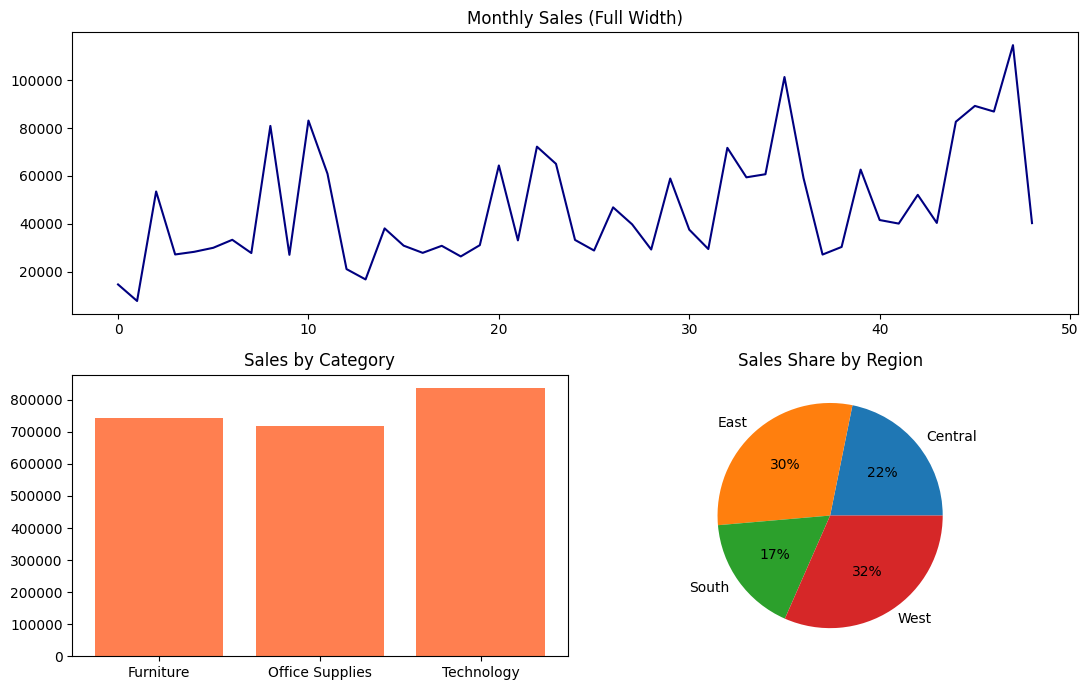

In [19]:
# subplot2grid - asymmetric layout (ek bada plot + do chhote)
fig = plt.figure(figsize=(11,7))
ax1 = plt.subplot2grid((2,2), (0,0), colspan=2)
ax2 = plt.subplot2grid((2,2), (1,0))
ax3 = plt.subplot2grid((2,2), (1,1))

ax1.plot(month_x, monthly_sales, color='navy')
ax1.set_title('Monthly Sales (Full Width)')

ax2.bar(categories, cat_total_sales, color='coral')
ax2.set_title('Sales by Category')

ax3.pie(reg_total_sales, labels=regions, autopct='%1.0f%%')
ax3.set_title('Sales Share by Region')

plt.tight_layout()
plt.show()

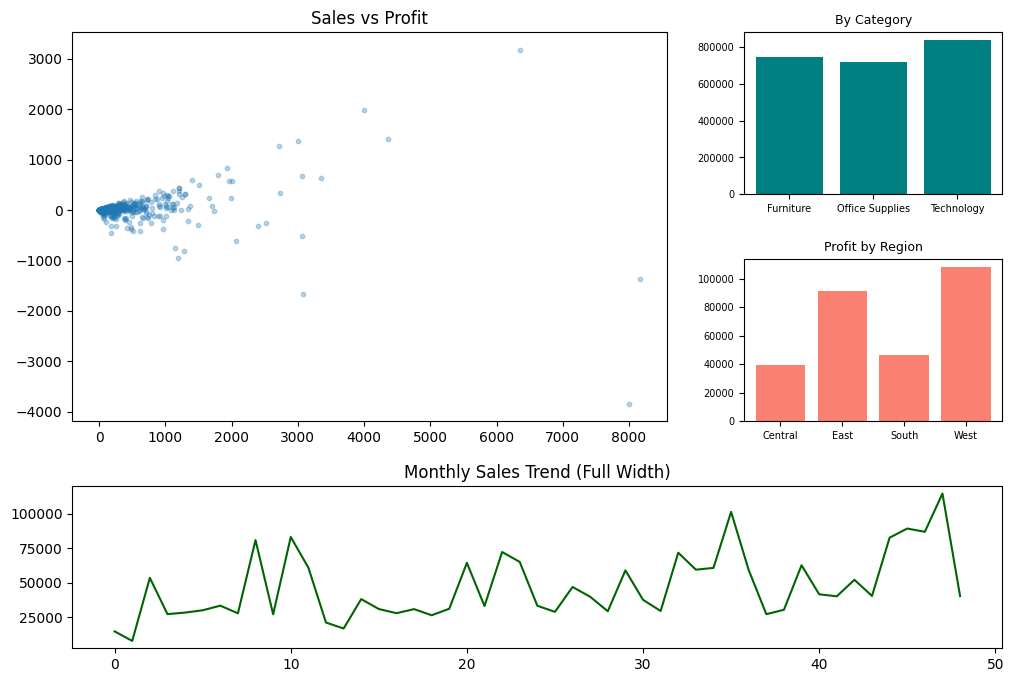

In [20]:
# GridSpec - flexible, custom-ratio grid layout
fig = plt.figure(figsize=(12,8))
gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

ax_main = fig.add_subplot(gs[0:2, 0:2])
ax_right1 = fig.add_subplot(gs[0, 2])
ax_right2 = fig.add_subplot(gs[1, 2])
ax_bottom = fig.add_subplot(gs[2, :])

ax_main.scatter(sales[:1000], profit[:1000], alpha=0.3, s=10)
ax_main.set_title('Sales vs Profit')

ax_right1.bar(categories, cat_total_sales, color='teal')
ax_right1.set_title('By Category', fontsize=9)
ax_right1.tick_params(labelsize=7)

ax_right2.bar(regions, reg_total_profit, color='salmon')
ax_right2.set_title('Profit by Region', fontsize=9)
ax_right2.tick_params(labelsize=7)

ax_bottom.plot(month_x, monthly_sales, color='darkgreen')
ax_bottom.set_title('Monthly Sales Trend (Full Width)')

plt.show()

## 🔟 Dual Axes — twinx()

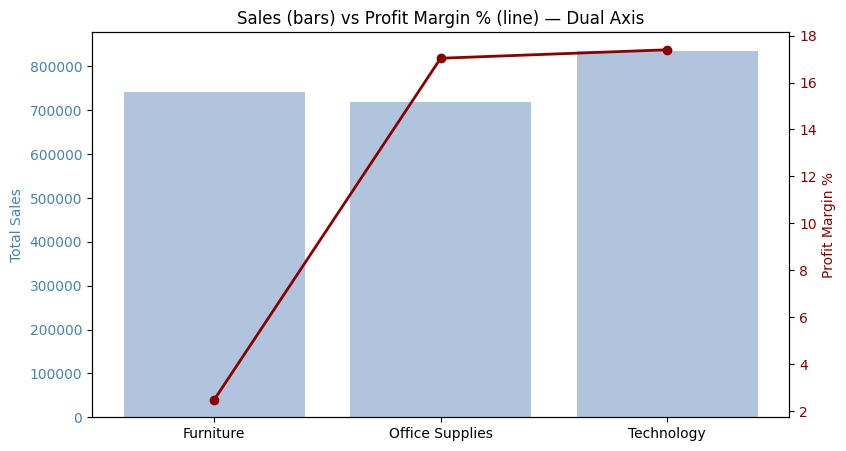

In [21]:
# Ek hi plot mein do different scales - Sales (bar) aur Profit Margin % (line) saath mein
margin_pct = (cat_total_profit / cat_total_sales) * 100

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.bar(categories, cat_total_sales, color='lightsteelblue', label='Total Sales')
ax1.set_ylabel('Total Sales', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(categories, margin_pct, color='darkred', marker='o', linewidth=2, label='Profit Margin %')
ax2.set_ylabel('Profit Margin %', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

ax1.set_title('Sales (bars) vs Profit Margin % (line) — Dual Axis')
plt.show()

## 1️⃣1️⃣ Annotations, Text & Arrows

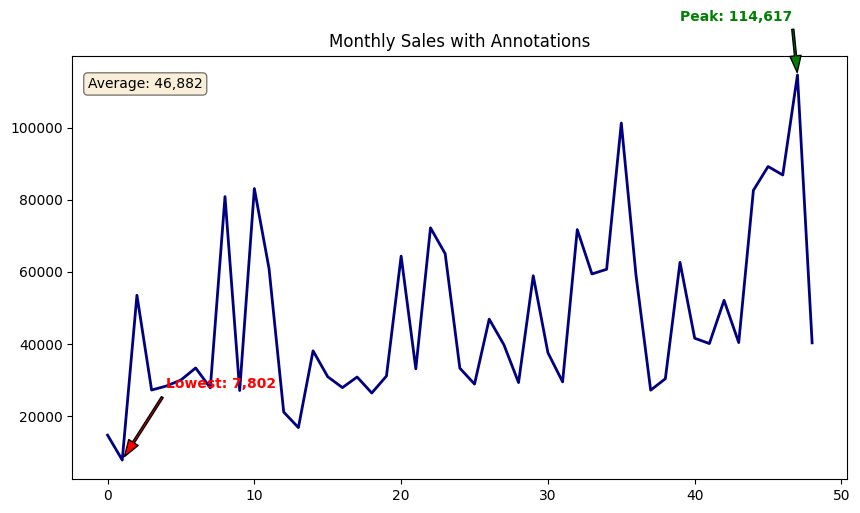

In [22]:
fig, ax = plt.subplots(figsize=(10,5.5))
ax.plot(month_x, monthly_sales, color='navy', linewidth=2)

peak_idx = np.argmax(monthly_sales)
low_idx = np.argmin(monthly_sales)

ax.annotate(f'Peak: {monthly_sales[peak_idx]:,.0f}',
            xy=(peak_idx, monthly_sales[peak_idx]),
            xytext=(peak_idx-8, monthly_sales[peak_idx]+15000),
            arrowprops=dict(facecolor='green', shrink=0.05, width=1.5, headwidth=8),
            fontsize=10, fontweight='bold', color='green')

ax.annotate(f'Lowest: {monthly_sales[low_idx]:,.0f}',
            xy=(low_idx, monthly_sales[low_idx]),
            xytext=(low_idx+3, monthly_sales[low_idx]+20000),
            arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
            fontsize=10, fontweight='bold', color='red')

ax.text(0.02, 0.95, f'Average: {monthly_sales.mean():,.0f}', transform=ax.transAxes,
        fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_title('Monthly Sales with Annotations')
plt.show()

## 1️⃣2️⃣ Colormaps & Colorbar

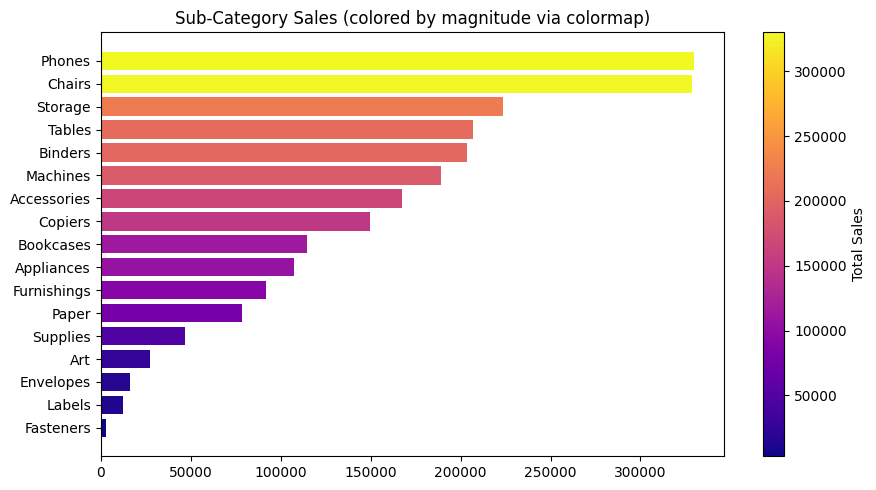

In [23]:
# Heatmap-style bar coloring using a colormap based on value
fig, ax = plt.subplots(figsize=(9,5))
norm_vals = (subcat_total_sales - subcat_total_sales.min()) / (subcat_total_sales.max() - subcat_total_sales.min())
colors = cm.plasma(norm_vals)
order = np.argsort(subcat_total_sales)

bars = ax.barh(subcats[order], subcat_total_sales[order], color=colors[order])
ax.set_title('Sub-Category Sales (colored by magnitude via colormap)')

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=subcat_total_sales.min(), vmax=subcat_total_sales.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Total Sales')
plt.tight_layout()
plt.show()

## 1️⃣3️⃣ Heatmaps — imshow()

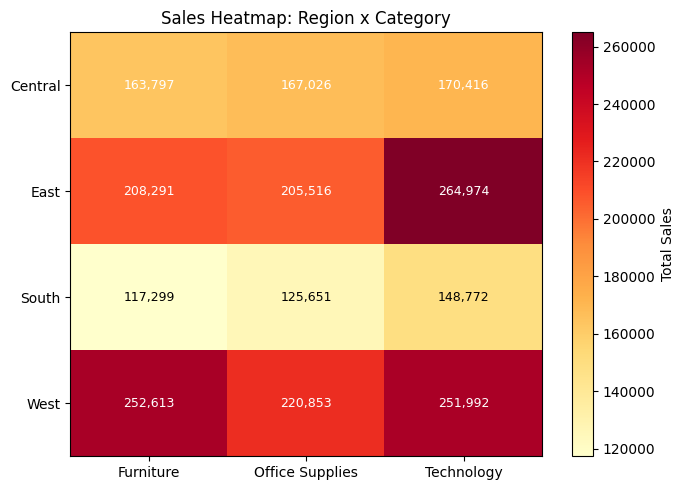

In [24]:
# Region x Category sales matrix banate hain aur imshow se heatmap banate hain
heat_matrix = np.zeros((len(regions), len(categories)))
for i, r in enumerate(regions):
    for j, c in enumerate(categories):
        mask = (region == r) & (category == c)
        heat_matrix[i, j] = sales[mask].sum()

fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(heat_matrix, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(categories)))
ax.set_xticklabels(categories)
ax.set_yticks(np.arange(len(regions)))
ax.set_yticklabels(regions)

# Har cell mein value likhna
for i in range(len(regions)):
    for j in range(len(categories)):
        ax.text(j, i, f'{heat_matrix[i,j]:,.0f}', ha='center', va='center',
                color='black' if heat_matrix[i,j] < heat_matrix.max()*0.6 else 'white', fontsize=9)

ax.set_title('Sales Heatmap: Region x Category')
plt.colorbar(im, ax=ax, label='Total Sales')
plt.tight_layout()
plt.show()

## 1️⃣4️⃣ Contour Plots

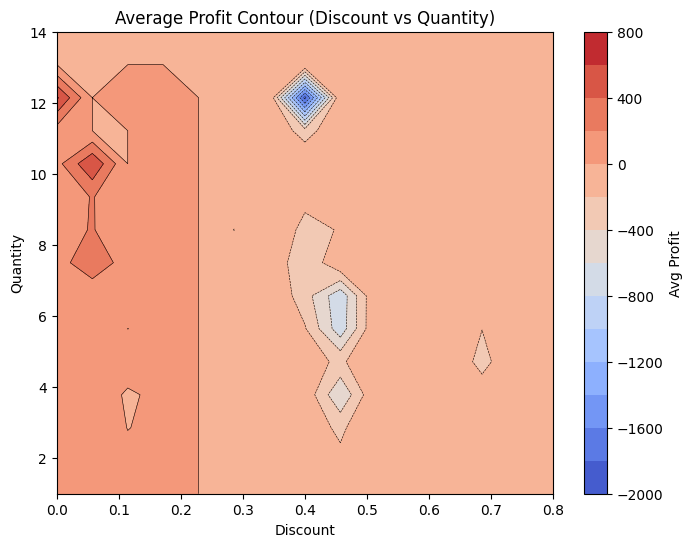

In [25]:
# Discount vs Quantity ke combination se average Profit ka synthetic contour surface
disc_bins = np.linspace(0, discount.max(), 15)
qty_bins = np.linspace(1, quantity.max(), 15)
X, Y = np.meshgrid(disc_bins, qty_bins)
Z = np.zeros_like(X)

for i in range(len(qty_bins)-1):
    for j in range(len(disc_bins)-1):
        mask = ((discount >= disc_bins[j]) & (discount < disc_bins[j+1]) &
                (quantity >= qty_bins[i]) & (quantity < qty_bins[i+1]))
        Z[i,j] = profit[mask].mean() if mask.sum() > 0 else 0

fig, ax = plt.subplots(figsize=(8,6))
cf = ax.contourf(X, Y, Z, levels=15, cmap='coolwarm')
cs = ax.contour(X, Y, Z, levels=15, colors='black', linewidths=0.4)
ax.set_xlabel('Discount')
ax.set_ylabel('Quantity')
ax.set_title('Average Profit Contour (Discount vs Quantity)')
plt.colorbar(cf, ax=ax, label='Avg Profit')
plt.show()

## 1️⃣5️⃣ Stem & Step Plots

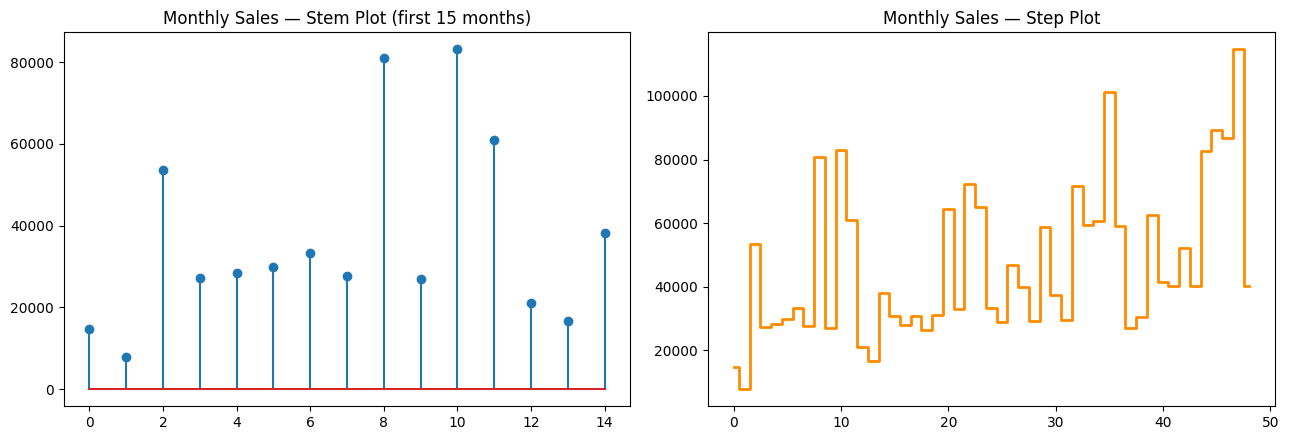

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

axes[0].stem(month_x[:15], monthly_sales[:15])
axes[0].set_title('Monthly Sales — Stem Plot (first 15 months)')

axes[1].step(month_x, monthly_sales, where='mid', color='darkorange', linewidth=2)
axes[1].set_title('Monthly Sales — Step Plot')

plt.tight_layout()
plt.show()

## 1️⃣6️⃣ Error Bars & fill_between()

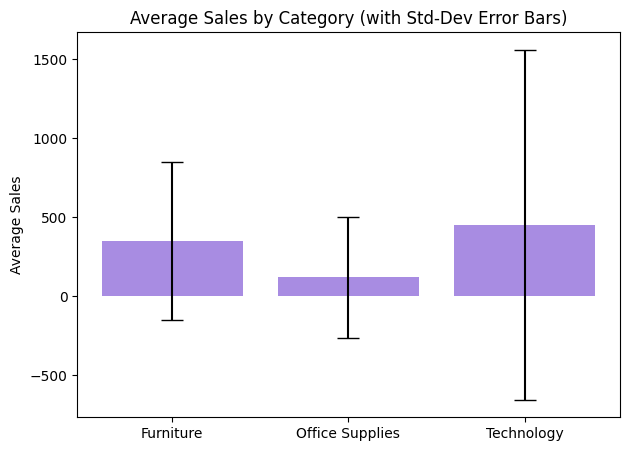

In [27]:
# Category-wise average Sales with standard deviation as error bars
cat_means = np.array([sales[category==c].mean() for c in categories])
cat_stds  = np.array([sales[category==c].std() for c in categories])

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(categories, cat_means, yerr=cat_stds, capsize=8, color='mediumpurple', alpha=0.8)
ax.set_title('Average Sales by Category (with Std-Dev Error Bars)')
ax.set_ylabel('Average Sales')
plt.show()

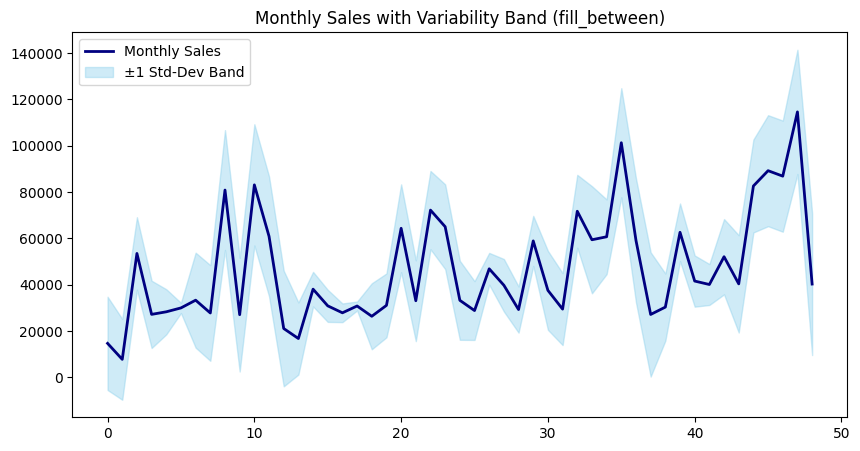

In [28]:
# fill_between - monthly sales ke around ek confidence band dikhana
rolling_std = np.array([monthly_sales[max(0,i-2):i+3].std() for i in range(len(monthly_sales))])

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(month_x, monthly_sales, color='navy', linewidth=2, label='Monthly Sales')
ax.fill_between(month_x, monthly_sales - rolling_std, monthly_sales + rolling_std,
                color='skyblue', alpha=0.4, label='±1 Std-Dev Band')
ax.set_title('Monthly Sales with Variability Band (fill_between)')
ax.legend()
plt.show()

## 1️⃣7️⃣ Date Axis Formatting — matplotlib.dates

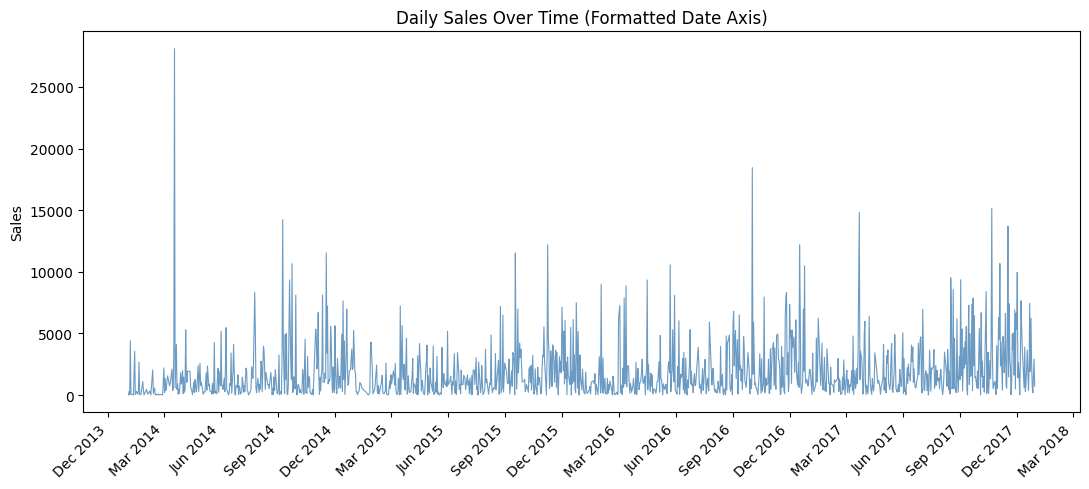

In [29]:
# Real dates ke saath time series plot, proper date formatting ke saath
daily_dates, daily_idx = np.unique(order_date, return_inverse=True)
daily_sales = np.bincount(daily_idx, weights=sales)

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(daily_dates, daily_sales, color='steelblue', linewidth=0.8, alpha=0.8)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=45)

ax.set_title('Daily Sales Over Time (Formatted Date Axis)')
ax.set_ylabel('Sales')
plt.tight_layout()
plt.show()

## 1️⃣8️⃣ Logarithmic Scale Axes

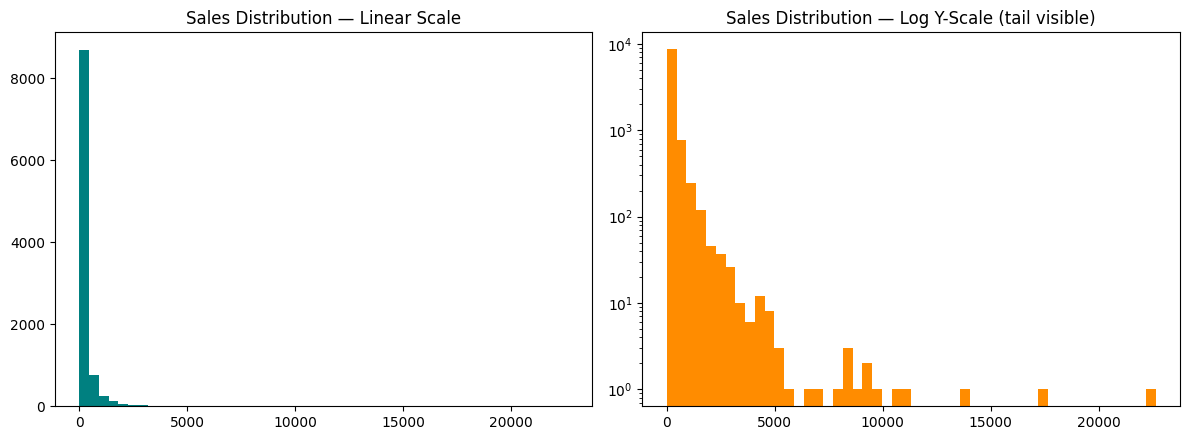

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].hist(sales, bins=50, color='teal')
axes[0].set_title('Sales Distribution — Linear Scale')

axes[1].hist(sales, bins=50, color='darkorange')
axes[1].set_yscale('log')
axes[1].set_title('Sales Distribution — Log Y-Scale (tail visible)')

plt.tight_layout()
plt.show()

## 1️⃣9️⃣ 3D Plotting — mpl_toolkits.mplot3d

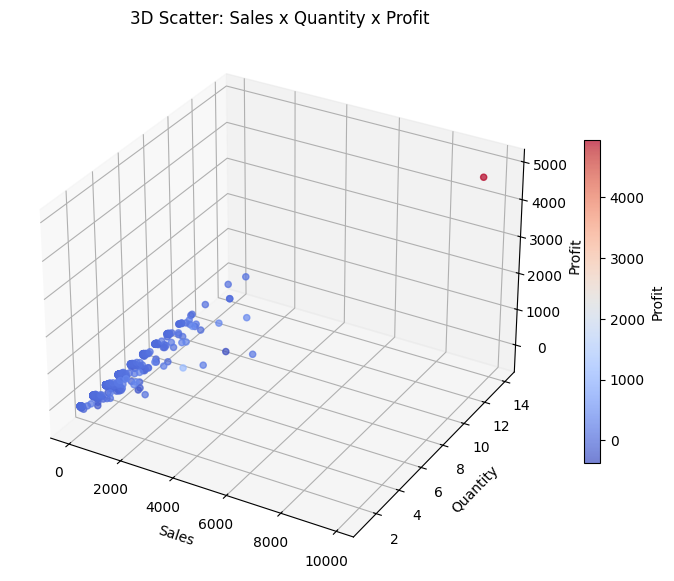

In [31]:
# 3D scatter - Sales, Quantity, Profit
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

sample_idx = np.random.default_rng(2).choice(len(sales), 500, replace=False)
sc = ax.scatter(sales[sample_idx], quantity[sample_idx], profit[sample_idx],
                 c=profit[sample_idx], cmap='coolwarm', alpha=0.7, s=20)

ax.set_xlabel('Sales')
ax.set_ylabel('Quantity')
ax.set_zlabel('Profit')
ax.set_title('3D Scatter: Sales x Quantity x Profit')
fig.colorbar(sc, ax=ax, shrink=0.6, label='Profit')
plt.show()

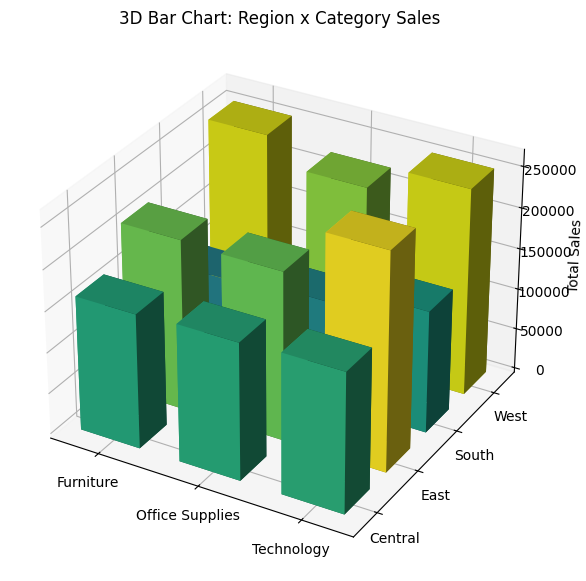

In [32]:
# 3D bar chart - Region x Category sales
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

_xx, _yy = np.meshgrid(np.arange(len(categories)), np.arange(len(regions)))
x_flat, y_flat = _xx.ravel(), _yy.ravel()
z_flat = heat_matrix.ravel()

ax.bar3d(x_flat, y_flat, np.zeros_like(z_flat), 0.6, 0.6, z_flat,
          color=plt.cm.viridis(z_flat/z_flat.max()), shade=True)

ax.set_xticks(np.arange(len(categories))+0.3)
ax.set_xticklabels(categories)
ax.set_yticks(np.arange(len(regions))+0.3)
ax.set_yticklabels(regions)
ax.set_zlabel('Total Sales')
ax.set_title('3D Bar Chart: Region x Category Sales')
plt.show()

## 2️⃣0️⃣ Plot Styles & rcParams Customization

In [33]:
print("Available styles (sample):", plt.style.available[:8])

Available styles (sample): ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast']


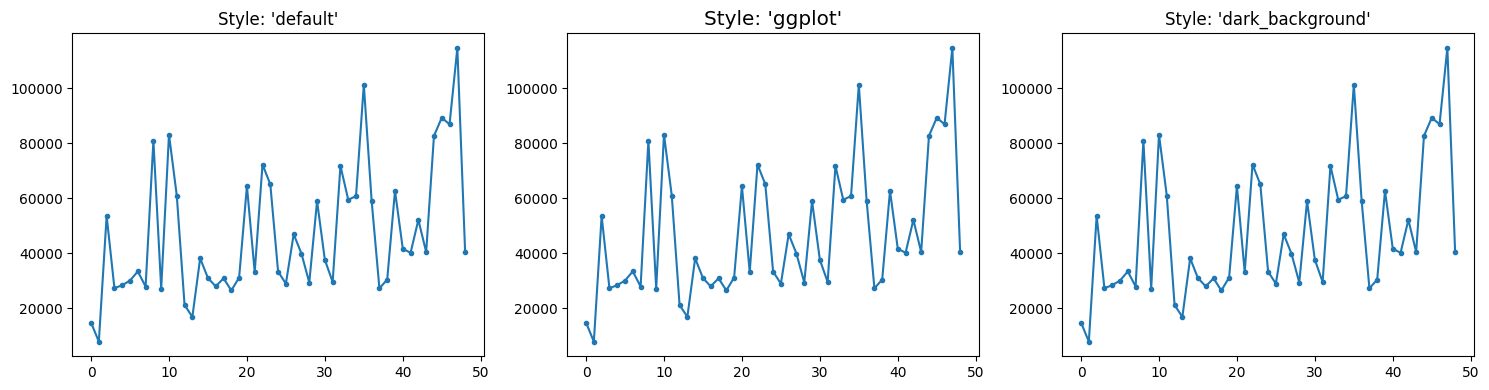

In [34]:
# Different built-in styles compare karna
fig, axes = plt.subplots(1, 3, figsize=(15,4))
styles_to_try = ['default', 'ggplot', 'dark_background']

for ax, style in zip(axes, styles_to_try):
    with plt.style.context(style):
        ax.plot(month_x, monthly_sales, marker='o', markersize=3)
        ax.set_title(f"Style: '{style}'")

plt.tight_layout()
plt.show()

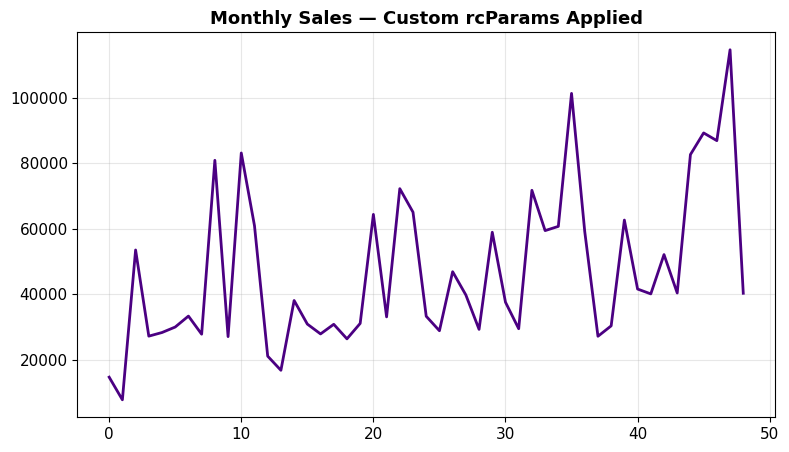

In [35]:
# Custom rcParams - global font/size/grid changes
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2
})

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(month_x, monthly_sales, color='indigo')
ax.set_title('Monthly Sales — Custom rcParams Applied')
plt.show()

# rcParams reset kar dete hain baaki notebook ke liye default pe
plt.rcParams.update(plt.rcParamsDefault)
plt.style.use('ggplot')

## 2️⃣1️⃣ Saving Figures — savefig()

Saved as category_sales_chart.png (dpi=200)


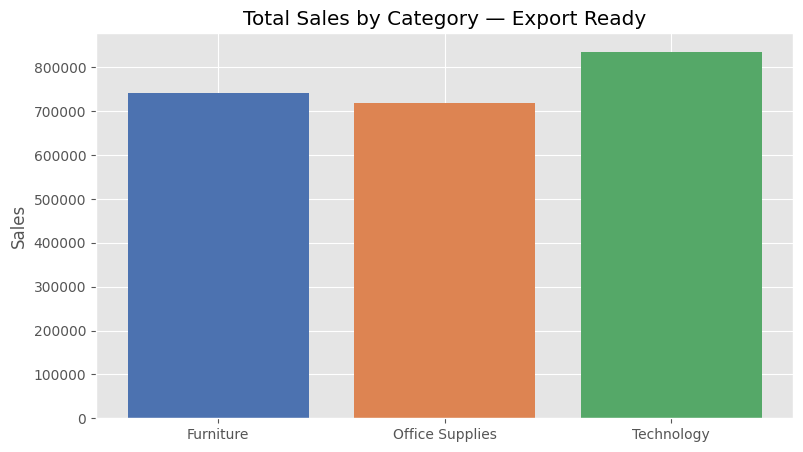

In [36]:
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(categories, cat_total_sales, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Total Sales by Category — Export Ready')
ax.set_ylabel('Sales')

# High-resolution PNG export
fig.savefig('category_sales_chart.png', dpi=200, bbox_inches='tight')
print("Saved as category_sales_chart.png (dpi=200)")
plt.show()

## 2️⃣2️⃣ Final Combined Dashboard

/tmp/ipykernel_485/4104238838.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(data_by_cat2, labels=categories, patch_artist=True, vert=False)


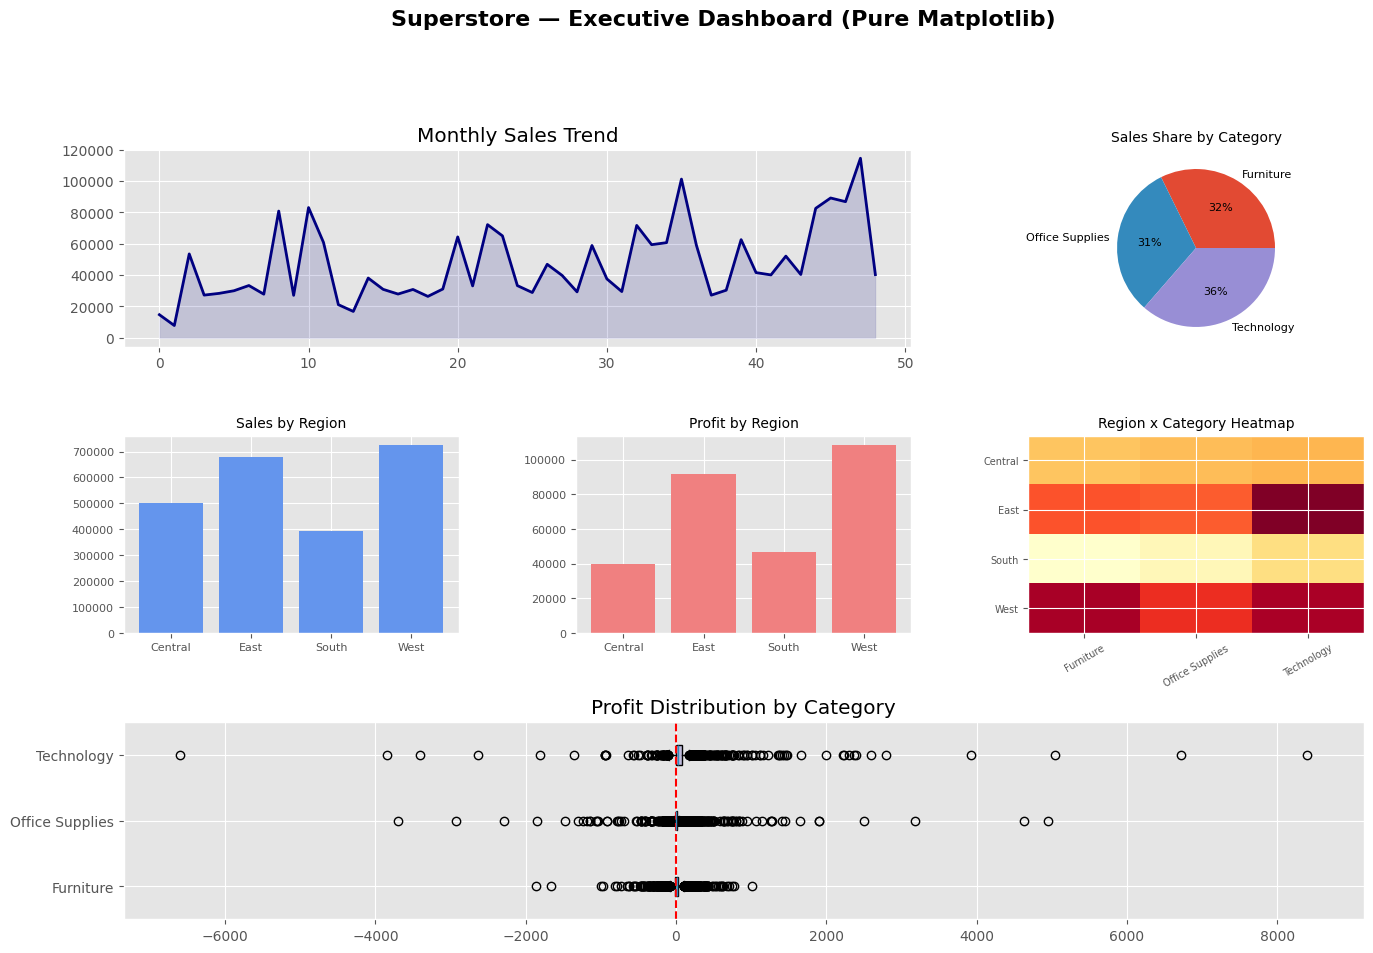

In [37]:
fig = plt.figure(figsize=(16,10))
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(month_x, monthly_sales, color='navy', linewidth=2)
ax1.fill_between(month_x, monthly_sales, alpha=0.15, color='navy')
ax1.set_title('Monthly Sales Trend')

ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(cat_total_sales, labels=categories, autopct='%1.0f%%', textprops={'fontsize':8})
ax2.set_title('Sales Share by Category', fontsize=10)

ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(regions, reg_total_sales, color='cornflowerblue')
ax3.set_title('Sales by Region', fontsize=10)
ax3.tick_params(labelsize=8)

ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(regions, reg_total_profit, color='lightcoral')
ax4.axhline(0, color='black', linewidth=0.7)
ax4.set_title('Profit by Region', fontsize=10)
ax4.tick_params(labelsize=8)

ax5 = fig.add_subplot(gs[1, 2])
im = ax5.imshow(heat_matrix, cmap='YlOrRd', aspect='auto')
ax5.set_xticks(np.arange(len(categories))); ax5.set_xticklabels(categories, fontsize=7, rotation=30)
ax5.set_yticks(np.arange(len(regions))); ax5.set_yticklabels(regions, fontsize=7)
ax5.set_title('Region x Category Heatmap', fontsize=10)

ax6 = fig.add_subplot(gs[2, :])
data_by_cat2 = [profit[category == c] for c in categories]
bp = ax6.boxplot(data_by_cat2, labels=categories, patch_artist=True, vert=False)
for patch, color in zip(bp['boxes'], ['#8dd3c7','#ffffb3','#bebada']):
    patch.set_facecolor(color)
ax6.axvline(0, color='red', linestyle='--')
ax6.set_title('Profit Distribution by Category')

fig.suptitle('Superstore — Executive Dashboard (Pure Matplotlib)', fontsize=16, fontweight='bold', y=1.02)
plt.show()